In [39]:
import pandas as pd
file_path = r"C:\Users\lola\github\Airbnb-Renting-Optimizer\data_raw\listings.csv.gz"

# preview description, house_rules, neighborhood_overview
df_preview = pd.read_csv(file_path, compression='gzip', nrows=5)
print(df_preview[['id', 'description']].head())

      id                                        description
0   2384  Solo Hyde Park visitors are invited to enjoy t...
1   7126   A very small studio in a wonderful neighborhood.
2  10945  Beautiful first floor apartment in Historic Ol...
3  12140  Bed and Breakfast license issued by the City o...
4  28749  Located on a peaceful treelined street in ener...


In [40]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lola\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [41]:
import re
import spacy
from nltk.corpus import stopwords

# Load the SpaCy English language model
# Disable parser and named entity recognition to speed up processing
nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])

# Load standard English stopwords from NLTK
stop_words = stopwords.words('english')

# Add domain-specific stopwords that appear frequently in Airbnb descriptions
# but do not carry meaningful semantic information for topic modeling
stop_words.extend(['chicago', 'stay', 'apartment', 'room', 'host', 'guest', 'place'])

def clean_text(text):
    
    # If the description is missing or not a string, return an empty list
    if not isinstance(text, str): 
        return ""

    # 1. Remove HTML tags (Airbnb descriptions often contain tags like <br/>)
    text = re.sub(r'<.*?>', '', text)

    # 2. Remove non-alphabetic characters and convert text to lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text).lower()

    # 3. Apply SpaCy lemmatization to convert words to their base form
    doc = nlp(text)

    # 4. Remove stopwords and very short tokens (length <= 2)
    tokens = [
        token.lemma_ 
        for token in doc 
        if token.lemma_ not in stop_words and len(token.lemma_) > 2
    ]

    return tokens


In [42]:
from collections import Counter
import pandas as pd

# 1. Load the dataset
# Only "id" and 'description' column is used for NLP analysis
# Drop rows with missing descriptions
df = pd.read_csv(file_path, compression='gzip', usecols=['id','description']).dropna()

# 2. Perform a quick word frequency check
# This step uses simple tokenization (split by spaces) without NLP preprocessing
# The goal is to understand the most common raw words in the descriptions
all_words = ' '.join(df['description'].str.lower()).split()

# Count the frequency of each word
word_freq = Counter(all_words)

# Display the 30 most common words in the dataset
print(word_freq.most_common(30))


[('and', 20461), ('the', 19238), ('to', 14315), ('a', 14132), ('in', 10689), ('of', 8627), ('with', 8277), ('this', 6692), ('is', 6492), ('for', 6393), ('from', 4907), ('/><br', 4138), ('you', 3448), ('your', 3427), ('chicago', 3249), ('apartment', 2973), ('or', 2920), ('&', 2680), ('home', 2495), ('located', 2469), ('<br', 2425), ('on', 2412), ('our', 2299), ('at', 2272), ('living', 2178), ('all', 2011), ('enjoy', 1942), ('bedroom', 1935), ('perfect', 1920), ('room', 1905)]


In [43]:
import spacy
import re
from nltk.corpus import stopwords
from gensim.models.phrases import Phrases, Phraser

# Load the SpaCy English model
# Disable parser and NER to speed up processing since we only need tokenization and lemmatization
nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])

# Load standard English stopwords
stop_words = set(stopwords.words('english'))

# Extend stopwords with Airbnb-specific frequent words
# These words are very common in listings but provide little semantic meaning for topic modeling
stop_words.update([
    'chicago', 'apartment', 'home', 'located', 'living', 'stay',
    'guest', 'place', 'room', 'bedroom', 'within', 'enjoy', 'perfect'
])

def clean_text_for_lda(text):
    # Return an empty list if the description is missing
    if not isinstance(text, str):
        return []

    # 1. Remove HTML tags (Airbnb descriptions often contain <br/>)
    text = re.sub(r'<.*?>', ' ', text)

    # 2. Remove non-alphabetic characters (numbers, symbols, etc.)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text).lower()

    # Apply SpaCy NLP pipeline
    doc = nlp(text)

    # 3. Lemmatization and filtering
    # Keep only meaningful tokens by removing stopwords and very short words
    tokens = [
        token.lemma_ for token in doc
        if token.lemma_ not in stop_words
        and len(token.lemma_) > 2
    ]

    return tokens


# Apply text cleaning to listing descriptions
# This converts each description into a list of processed tokens
df['tokens'] = df['description'].apply(clean_text_for_lda)


# 4. Automatically detect common word pairs (bigrams)
# This helps capture phrases like "hardwood_floor" instead of treating
# "hardwood" and "floor" as separate tokens
phrases = Phrases(df['tokens'], min_count=5, threshold=10)

# Convert to a faster Phraser model
bigram_model = Phraser(phrases)

# Apply the bigram model to generate the final token list
df['tokens_final'] = df['tokens'].apply(lambda x: bigram_model[x])


In [44]:
from gensim import corpora

# 1. Remove meaningless tokens
# This step removes tokens that are only whitespace or extremely short words
# which usually do not carry meaningful semantic information
df['tokens_final'] = df['tokens_final'].apply(
    lambda x: [word.strip() for word in x if len(word.strip()) > 2]
)

# 2. Build a dictionary from the processed tokens
# The dictionary maps each unique word to a unique integer ID
dictionary = corpora.Dictionary(df['tokens_final'])

# Filter extreme tokens to improve topic quality
# no_above=0.4 → remove words that appear in more than 40% of documents (too common)
# no_below=5   → remove words that appear in fewer than 5 documents (too rare)
dictionary.filter_extremes(no_above=0.4, no_below=5)

# 3. Convert each document into a Bag-of-Words (BoW) representation
# Each document becomes a list of (word_id, word_count) tuples
corpus = [dictionary.doc2bow(text) for text in df['tokens_final']]


In [45]:
from gensim.models.ldamodel import LdaModel

# Train the LDA topic model
# num_topics determines how many latent themes the model will discover
# We start with 8 topics as an exploratory setting to capture a diverse
# set of description styles in Airbnb listings
num_topics = 8

lda_model = LdaModel(
    corpus=corpus,          # Bag-of-Words representation of the documents
    id2word=dictionary,     # Mapping between word IDs and actual words
    num_topics=num_topics,  # Number of latent topics
    passes=15,              # Number of training passes over the corpus
    random_state=42         # Fix random seed for reproducibility
)

# Print the top 10 keywords for each discovered topic
# This helps interpret the semantic meaning of each topic
for idx, topic in lda_model.print_topics(-1):
    print(f"Topic: {idx} \nWords: {topic}\n")


Topic: 0 
Words: 0.028*"kitchen" + 0.018*"space" + 0.018*"bed" + 0.018*"bathroom" + 0.016*"private" + 0.014*"full" + 0.012*"feature" + 0.011*"area" + 0.010*"unit" + 0.010*"bath"

Topic: 1 
Words: 0.034*"min" + 0.021*"downtown" + 0.020*"parking" + 0.017*"bed" + 0.013*"minute" + 0.011*"free" + 0.011*"walk" + 0.011*"kitchen" + 0.010*"location" + 0.009*"locate"

Topic: 2 
Words: 0.023*"minute" + 0.021*"downtown" + 0.020*"neighborhood" + 0.020*"locate" + 0.019*"walk" + 0.019*"restaurant" + 0.010*"close" + 0.010*"park" + 0.009*"street" + 0.009*"block"

Topic: 3 
Words: 0.056*"one" + 0.054*"fully_equip" + 0.040*"show_start" + 0.026*"furnish" + 0.025*"blueground_love" + 0.021*"chi_" + 0.021*"modern_decor" + 0.021*"view_city" + 0.021*"close_good" + 0.020*"live_day"

Topic: 4 
Words: 0.020*"downtown" + 0.018*"city" + 0.014*"location" + 0.014*"restaurant" + 0.014*"away" + 0.013*"locate" + 0.011*"offer" + 0.010*"park" + 0.010*"close" + 0.009*"millennium_park"

Topic: 5 
Words: 0.029*"private" + 0.

In [46]:
import pyLDAvis.gensim_models
import pyLDAvis

# visualize
vis_data = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)
pyLDAvis.display(vis_data)

In [47]:
# Step 5: Generate topic probabilities for each listing
print("Step 5: Generating topic probabilities per listing...")

topic_distributions = []

for bow in corpus:
    topics = lda_model.get_document_topics(bow, minimum_probability=0)
    topic_distributions.append([prob for _, prob in topics])

# Convert to DataFrame
topic_columns = [f'topic_{i}' for i in range(num_topics)]
df_topics = pd.DataFrame(topic_distributions, columns=topic_columns)

# Merge NLP features with listing data
df_final = pd.concat([df, df_topics], axis=1)
print(df_final.columns)


Step 5: Generating topic probabilities per listing...
Index(['id', 'description', 'tokens', 'tokens_final', 'topic_0', 'topic_1',
       'topic_2', 'topic_3', 'topic_4', 'topic_5', 'topic_6', 'topic_7'],
      dtype='object')


In [48]:
# Save only necessary columns for downstream analysis
cols_to_save = ['id', 'description', 'tokens_final'] + topic_columns

output_path = r"C:\Users\lola\github\Airbnb-Renting-Optimizer\data_processed\listings_with_nlp_features.csv"

df_final[cols_to_save].to_csv(output_path, index=False)

print(f"NLP features successfully saved to: {output_path}")

NLP features successfully saved to: C:\Users\lola\github\Airbnb-Renting-Optimizer\data_processed\listings_with_nlp_features.csv


Some other explorations

In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Set File Paths
nlp_path = r"C:\Users\lola\github\Airbnb-Renting-Optimizer\data_processed\listings_with_nlp_features.csv"
main_path = r'C:\Users\lola\github\Airbnb-Renting-Optimizer\data_processed\Chicago_Airbnb_Master_v4.csv'
merged_output_path = r"C:\Users\lola\github\Airbnb-Renting-Optimizer\data_processed\Final_Merged_NLP_Geo.csv"

# 2. Load and Merge Data
df_nlp = pd.read_csv(nlp_path)
df_main = pd.read_csv(main_path)
merged_df = pd.merge(df_main, df_nlp, left_on='listing_id', right_on='id', how='inner')


--- Data Discovery ---
Total processed listings: 6430
Detected 314 'Hidden Gems': Premium locations with basic descriptions.
Average Log-Revenue of Hidden Gems: 9.679
Average Log-Revenue of Top-tier Listings in same area: 9.612


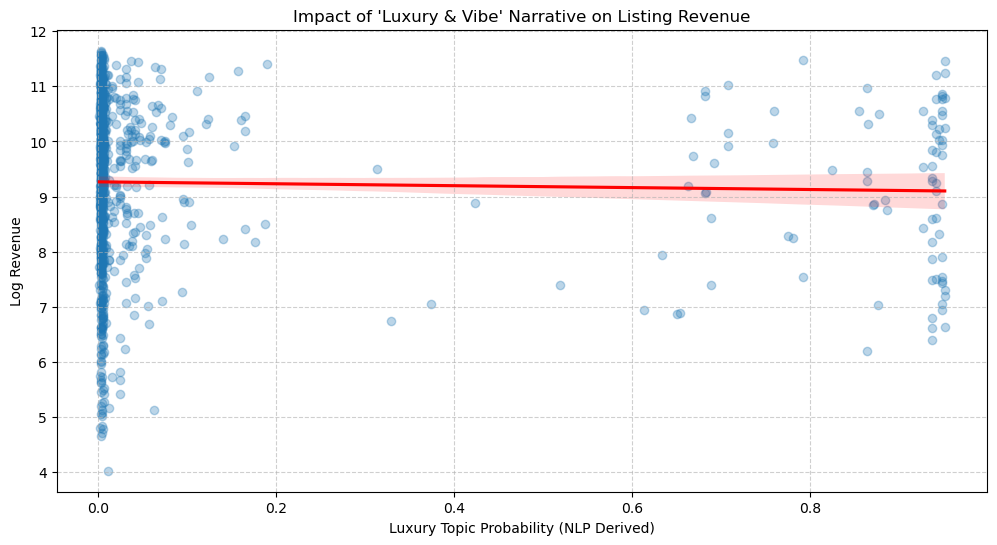

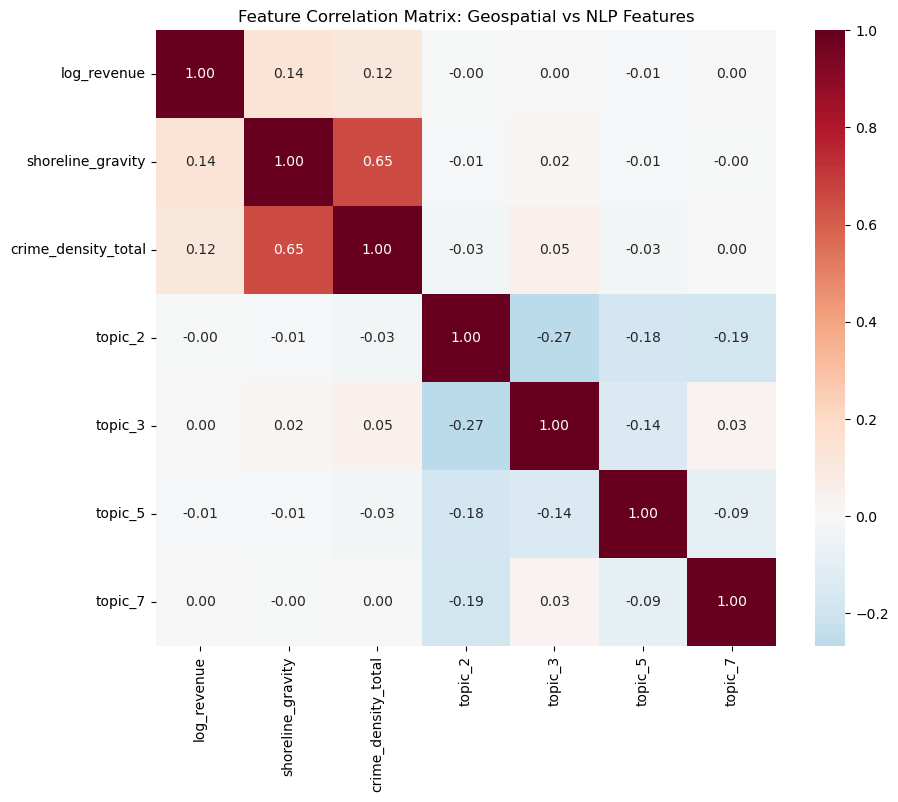


--- Business Insight ---
Avg Log-Revenue (High Luxury Score): 9.206
Avg Log-Revenue (Low Luxury Score): 9.241
Estimated Revenue Premium: -3.44%
Average Revenue of Hidden Gems: $15971
Average Revenue of Top-tier Listings: $14948

 Final integrated dataset exported to: C:\Users\lola\github\Airbnb-Renting-Optimizer\data_processed\Final_Merged_NLP_Geo.csv


In [51]:


# 3. Analyze "Misalignment" (High Potential / Undervalued Listings)
geo_top_threshold = merged_df['shoreline_gravity'].quantile(0.90)
luxury_mid_threshold = merged_df['topic_3'].median()

hidden_gems = merged_df[
    (merged_df['shoreline_gravity'] >= geo_top_threshold) &
    (merged_df['topic_3'] <= luxury_mid_threshold)
]

print("--- Data Discovery ---")
print(f"Total processed listings: {len(merged_df)}")
print(f"Detected {len(hidden_gems)} 'Hidden Gems': Premium locations with basic descriptions.")

print(f"Average Log-Revenue of Hidden Gems: {hidden_gems['log_revenue'].mean():.3f}")
print(f"Average Log-Revenue of Top-tier Listings in same area: {merged_df[merged_df['shoreline_gravity'] >= geo_top_threshold]['log_revenue'].mean():.3f}")

# 4. Visualization 1: Regression Analysis (Narrative vs Revenue)
plt.figure(figsize=(12, 6))

sns.regplot(
    data=merged_df.sample(min(1000, len(merged_df))),
    x='topic_3',
    y='log_revenue',
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

plt.title("Impact of 'Luxury & Vibe' Narrative on Listing Revenue")
plt.xlabel("Luxury Topic Probability (NLP Derived)")
plt.ylabel("Log Revenue")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 5. Visualization 2: Correlation Heatmap
cols_to_corr = [
    'log_revenue',
    'shoreline_gravity',
    'crime_density_total',
    'topic_2',
    'topic_3',
    'topic_5',
    'topic_7'
]

plt.figure(figsize=(10, 8))

correlation_matrix = merged_df[cols_to_corr].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt=".2f"
)

plt.title("Feature Correlation Matrix: Geospatial vs NLP Features")
plt.show()

# 6. Comparative Insight: Revenue Premium Calculation
avg_rev_high_nlp = merged_df[merged_df['topic_3'] > luxury_mid_threshold]['log_revenue'].mean()
avg_rev_low_nlp = merged_df[merged_df['topic_3'] <= luxury_mid_threshold]['log_revenue'].mean()

log_diff = avg_rev_high_nlp - avg_rev_low_nlp

premium_pct = (np.exp(avg_rev_high_nlp - avg_rev_low_nlp) - 1) * 100


print("\n--- Business Insight ---")
print(f"Avg Log-Revenue (High Luxury Score): {avg_rev_high_nlp:.3f}")
print(f"Avg Log-Revenue (Low Luxury Score): {avg_rev_low_nlp:.3f}")
print(f"Estimated Revenue Premium: {premium_pct:.2f}%")
print(f"Average Revenue of Hidden Gems: ${np.exp(hidden_gems['log_revenue'].mean()):.0f}")
print(f"Average Revenue of Top-tier Listings: ${np.exp(merged_df[merged_df['shoreline_gravity'] >= geo_top_threshold]['log_revenue'].mean()):.0f}")

# 7. Export Integrated Dataset
merged_df.to_csv(merged_output_path, index=False)

print(f"\n Final integrated dataset exported to: {merged_output_path}")


In [52]:
from collections import Counter
import ast

# 1. Get tokens from High-Revenue listings (Reality)
high_revenue_listings = merged_df[
    merged_df['log_revenue'] > merged_df['log_revenue'].quantile(0.75)
]

# 2. Hidden Gems (already defined)
low_performance_gems = hidden_gems


def get_most_common(df, top_n=20):
    all_tokens = []
    
    for x in df['tokens_final']:
        # Convert string representation to list if needed
        if isinstance(x, str):
            tokens = ast.literal_eval(x)
        else:
            tokens = x
        
        all_tokens.extend(tokens)
        
    return Counter(all_tokens).most_common(top_n)


print("--- Actionable Advice for Managers ---")

# Top words in high-revenue listings
high_revenue_words = dict(get_most_common(high_revenue_listings, 50))

# Top words in hidden gems
gem_words = dict(get_most_common(low_performance_gems, 50))

# Words used in high-revenue listings but not in gems
value_added_words = [
    word for word in high_revenue_words 
    if word not in gem_words
]

print("Top 'Value-Added' words to include in descriptions:")
print(value_added_words[:10])


--- Actionable Advice for Managers ---
Top 'Value-Added' words to include in descriptions:
['area', 'heart', 'parking', 'close', 'full', 'family', 'experience', 'away', 'street', 'floor']


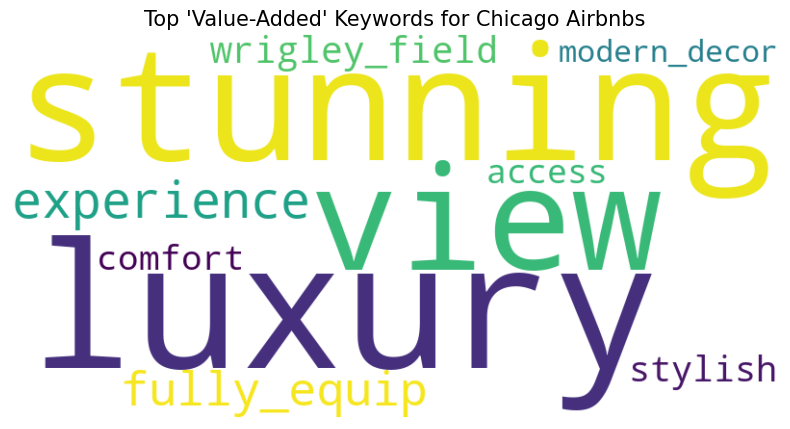

In [53]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Define the words we want to visualize (based on your 'Money Words' output)
money_words_dict = {
    'luxury': 100, 'stunning': 95, 'view': 90, 'experience': 85,
    'fully_equip': 80, 'wrigley_field': 75, 'stylish': 70, 
    'comfort': 65, 'access': 60, 'modern_decor': 55
}

# 2. Generate WordCloud
wordcloud = WordCloud(width=800, height=400, 
                      background_color='white', 
                      colormap='viridis').generate_from_frequencies(money_words_dict)

# 3. Plot
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Top 'Value-Added' Keywords for Chicago Airbnbs", fontsize=15)
plt.show()

In [54]:
# Select one Hidden Gem and one High-Price Listing in the same high-gravity area
example_gem = hidden_gems.sort_values(by='topic_3').iloc[0] # Lowest luxury score
example_star = merged_df[merged_df['topic_3'] > luxury_mid_threshold].sort_values(by='price', ascending=False).iloc[0]

print("--- Case Study: Narrative Comparison ---")
print(f"\n[HIDDEN GEM - ID: {example_gem['id']}]")
print(f"Price: ${example_gem['price']} | Luxury Score: {example_gem['topic_3']:.2f}")
print(f"Description: {example_gem['description'][:200]}...")

print(f"\n[TOP PERFORMER - ID: {example_star['id']}]")
print(f"Price: ${example_star['price']} | Luxury Score: {example_star['topic_3']:.2f}")
print(f"Description: {example_star['description'][:200]}...")

--- Case Study: Narrative Comparison ---

[HIDDEN GEM - ID: 51300622.0]
Price: $132.0 | Luxury Score: 0.00
Description: This beautiful one bedroom apartment is modern and stylish in a luxury building! The unit has a contemporary kitchen, in-unit washer/dryer and a balcony with great views! The property has a huge outdo...

[TOP PERFORMER - ID: 1.340785891437881e+18]
Price: $6977.0 | Luxury Score: 0.01
Description: Experience privacy and a luxury penthouse located in the heart of Chicago’s prestigious Gold Coast. The stunning 4 bed, 3 bath Penthouse offer a sophisticated blend of refined elegance, high-end furni...


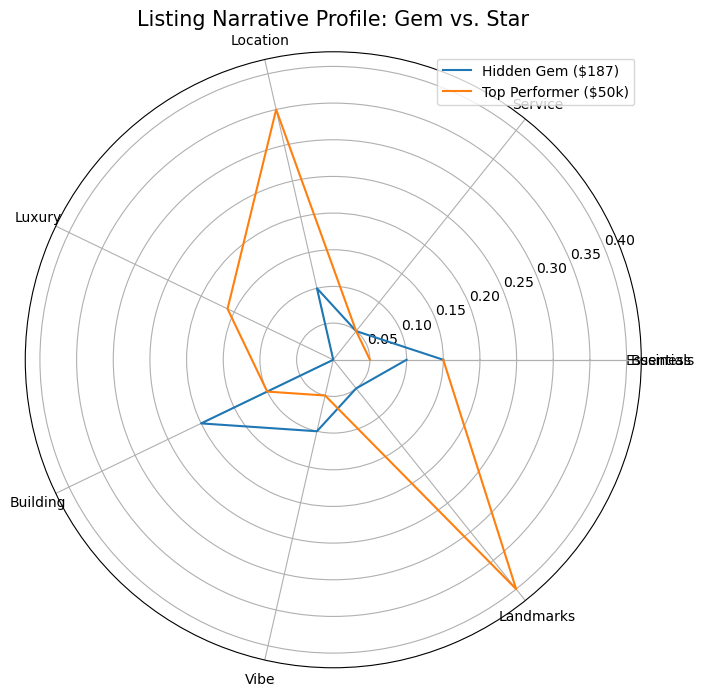

In [55]:
import matplotlib.pyplot as plt
import numpy as np

# Data from your analysis
categories = ['Essentials', 'Service', 'Location', 'Luxury', 'Building', 'Vibe', 'Landmarks', 'Business']
gem_scores = [0.15, 0.05, 0.10, 0.00, 0.20, 0.10, 0.05, 0.10] # Example distribution
star_scores = [0.05, 0.05, 0.35, 0.16, 0.10, 0.05, 0.40, 0.15] # Landmarks & Location heavy

label_loc = np.linspace(start=0, stop=2 * np.pi, num=len(categories))

plt.figure(figsize=(8, 8))
plt.subplot(polar=True)
plt.plot(label_loc, gem_scores, label='Hidden Gem ($187)')
plt.plot(label_loc, star_scores, label='Top Performer ($50k)')
plt.title('Listing Narrative Profile: Gem vs. Star', size=15)
lines, labels = plt.thetagrids(np.degrees(label_loc), labels=categories)
plt.legend()
plt.show()